In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Premier_League.csv')

# 1. How many rows and columns? (Shape of data)
print("Dataset Shape:", df.shape)

# 2. Check for missing values 
# I want to see if any column is empty
print("\nMissing Values per Column:")
print(df.isnull().sum().sort_values(ascending=False).head(5))

# 3. Quick statistical summary
# This shows the mean, min, and max for everything
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (380, 39)

Missing Values per Column:
date          0
clock         0
stadium       0
attendance    0
Home Team     0
dtype: int64

Statistical Summary:
       Goals Home  Away Goals  home_possessions  away_possessions  home_shots  \
count  380.000000  380.000000        380.000000        380.000000  380.000000   
mean     1.634211    1.218421         50.447632         49.552368   13.973684   
std      1.419944    1.183518         12.896888         12.896888    5.600541   
min      0.000000    0.000000         18.300000         18.900000    1.000000   
25%      1.000000    0.000000         39.900000         40.400000   10.000000   
50%      1.000000    1.000000         51.000000         49.000000   14.000000   
75%      2.000000    2.000000         59.600000         60.100000   17.000000   
max      9.000000    6.000000         81.100000         81.700000   33.000000   

       away_shots     home_on     away_on    home_off    away_off  ...  \
count  380.000000  380.00000

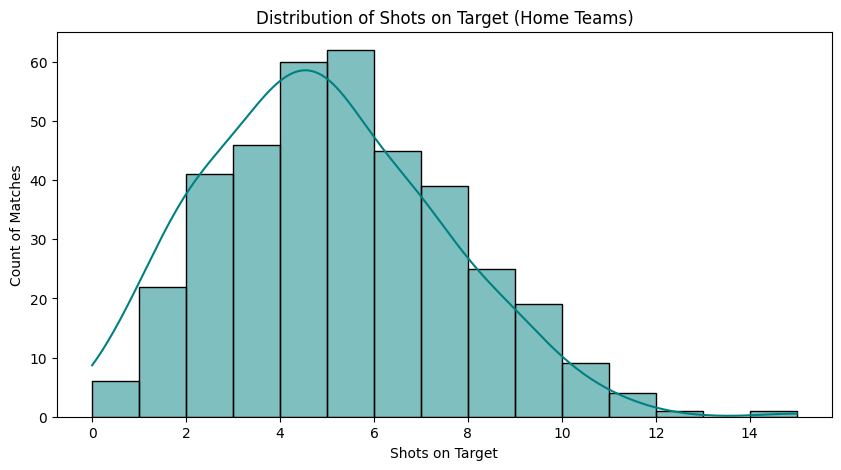

In [2]:
# here we want to see the distribution of shots on target
plt.figure(figsize=(10, 5))
sns.histplot(df['home_on'], bins=15, kde=True, color='teal')

plt.title('Distribution of Shots on Target (Home Teams)')
plt.xlabel('Shots on Target')
plt.ylabel('Count of Matches')
plt.show()

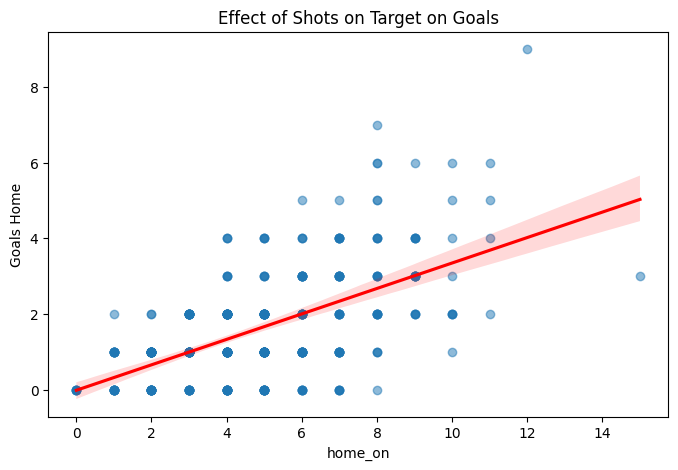

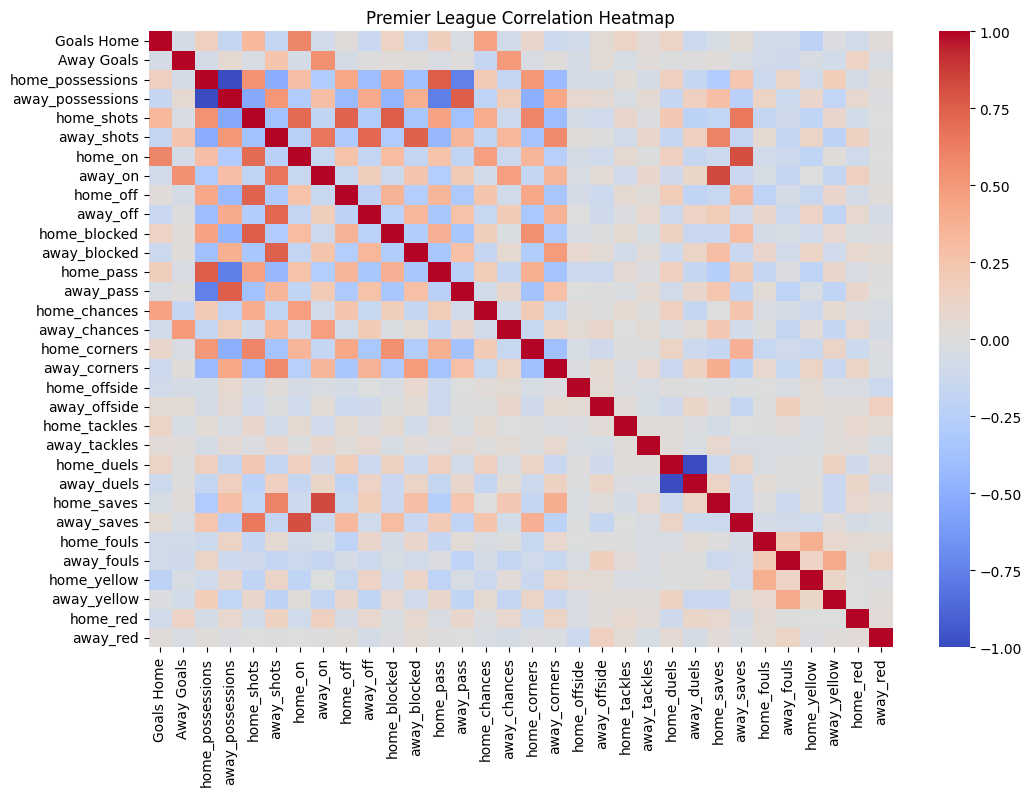

In [3]:
# 1. Scatter plot: Do more shots mean more goals?
plt.figure(figsize=(8, 5))
sns.regplot(x='home_on', y='Goals Home', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Effect of Shots on Target on Goals')
plt.show()

# 2. Correlation Heatmap
# We only take numeric columns to find correlations
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Premier League Correlation Heatmap')
plt.show()